In [2]:
import torch
import torch.nn as nn
import torchvision.datasets as datasets
import torchvision.transforms as transforms
import torch_directml
import matplotlib.pyplot as plt
from PIL import Image

KeyboardInterrupt: 

KeyboardInterrupt: 

In [2]:
for i in range(torch_directml.device_count()):
    print(f"Устройство [{i}]: {torch_directml.device_name(i)}")

Устройство [0]: AMD Radeon RX 6800S 
Устройство [1]: AMD Radeon(TM) Graphics 


In [3]:
input_size = 28 * 28    # 28 * 28 pixel image
hidden_size = 400       # hidden_layer
out_size = 10           # 0-9 numbers
epochs = 10             # epoch number
batch_size = 100        # batch size
learning_rate = 0.001   # learning rate

In [4]:
train_dataset = datasets.MNIST(root='./source',
                               train=True,
                               transform=transforms.ToTensor(),
                               download=True)
test_dataset = datasets.MNIST(root='./source',
                              train=False,
                              transform=transforms.ToTensor())

In [5]:
train_loader = torch.utils.data.DataLoader(dataset=train_dataset,
                                           batch_size=batch_size,
                                           shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset,
                                          batch_size=batch_size,
                                          shuffle=False)

In [6]:
class Net(nn.Module):
    def __init__(self, input_size, hidden_size, out_size):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, out_size)
    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        out = self.relu(out)
        out = self.fc3(out)
        return out

In [7]:
net = Net(input_size, hidden_size, out_size)
if torch.cuda.is_available():
    device = torch.device("cuda:0")
elif torch_directml.is_available():
    device = torch_directml.device()
else:
    device = torch.device("cpu")
net = net.to(device)
criterion = nn.CrossEntropyLoss(reduction='mean')
optimizer = torch.optim.AdamW(net.parameters(), lr=learning_rate, weight_decay=0.01)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

In [8]:
net.parameters

<bound method Module.parameters of Net(
  (fc1): Linear(in_features=784, out_features=400, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=400, out_features=400, bias=True)
  (fc3): Linear(in_features=400, out_features=10, bias=True)
)>

In [9]:
net.train()
for epoch in range(epochs):
    correct_train = 0
    total_train = 0
    for i, (image, label) in enumerate(train_loader):
        # Flattening all images
        image = image.view(-1, 28 * 28).to(device)
        label = label.to(device)
        # Drop previous grads
        optimizer.zero_grad()
        # Get new predictions
        output = net(image)
        _, predicted = torch.max(output.data, 1)
        # Update statistics
        total_train += len(label)
        correct_train += (predicted == label).sum().item()
        # Calculate loss and backprop
        loss = criterion(output, label)
        loss.backward()
        optimizer.step()
        # Visualization
        if (i + 1) % 100 == 0:
            print(f"Epoch [{epoch + 1}/{epochs}]")
            print(f"Iteration [{i + 1}/{len(train_dataset) // batch_size}]")
            print(f"Training loss: {loss.item()}")
            print(f"Training accuracy: {correct_train / total_train * 100}%")
            print()
    scheduler.step()
net.eval()
print("Done")

C:\Alexey\Projects\Udemy\NN_learning\.venv\Lib\site-packages\torch\optim\adamw.py:529: UserWarning: The operator 'aten::lerp.Scalar_out' is not currently supported on the DML backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at C:\__w\1\s\pytorch-directml-plugin\torch_directml\csrc\dml\dml_cpu_fallback.cpp:17.)
  torch._foreach_lerp_(device_exp_avgs, device_grads, 1 - beta1)


Epoch [1/10]
Iteration [100/600]
Training loss: 0.344573438167572
Training accuracy: 82.78%

Epoch [1/10]
Iteration [200/600]
Training loss: 0.4233289361000061
Training accuracy: 87.395%

Epoch [1/10]
Iteration [300/600]
Training loss: 0.14451128244400024
Training accuracy: 89.56%

Epoch [1/10]
Iteration [400/600]
Training loss: 0.2899842858314514
Training accuracy: 90.7925%

Epoch [1/10]
Iteration [500/600]
Training loss: 0.07614804804325104
Training accuracy: 91.732%

Epoch [1/10]
Iteration [600/600]
Training loss: 0.08328568190336227
Training accuracy: 92.4%

Epoch [2/10]
Iteration [100/600]
Training loss: 0.13786743581295013
Training accuracy: 96.56%

Epoch [2/10]
Iteration [200/600]
Training loss: 0.07983507961034775
Training accuracy: 96.71%

Epoch [2/10]
Iteration [300/600]
Training loss: 0.20749732851982117
Training accuracy: 96.79666666666667%

Epoch [2/10]
Iteration [400/600]
Training loss: 0.049757055938243866
Training accuracy: 96.8575%

Epoch [2/10]
Iteration [500/600]
Tra

In [10]:
correct = 0
total = 0
for image, label in test_loader:
    image = image.view(-1, 28 * 28).to(device)
    label = label.to(device)
    output = net    (image)
    _, predicted = torch.max(output.data, 1)
    total += len(label)
    correct += (predicted == label).sum().item()
print(f"Final accuracy: {correct / total * 100}%")

Final accuracy: 98.42999999999999%


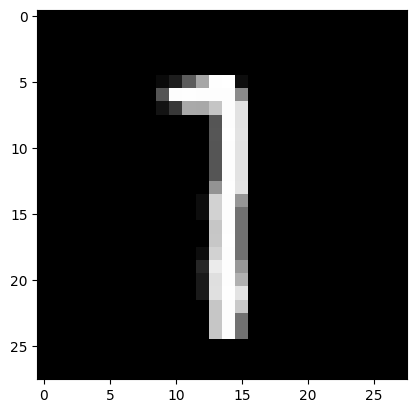

Predicted value: 1
Actual value: 7



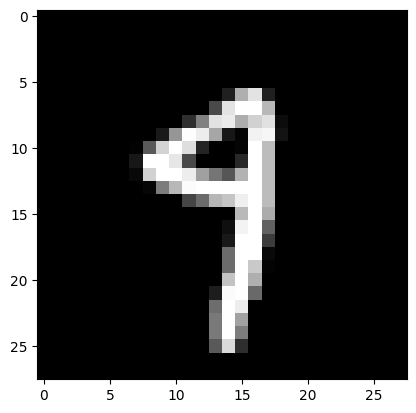

Predicted value: 9
Actual value: 4



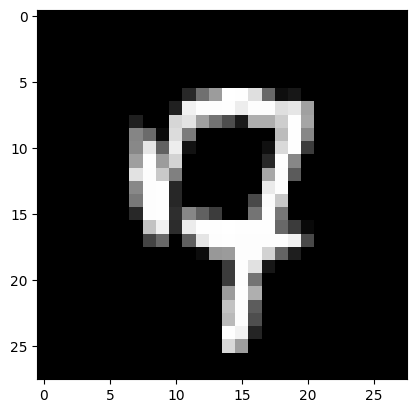

Predicted value: 9
Actual value: 7



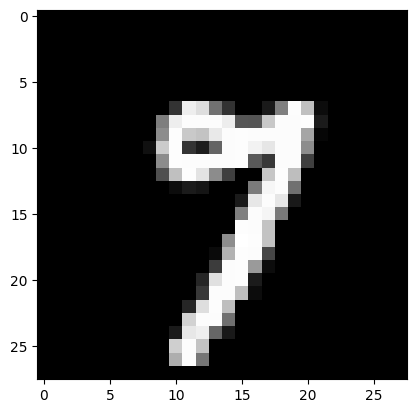

Predicted value: 7
Actual value: 9



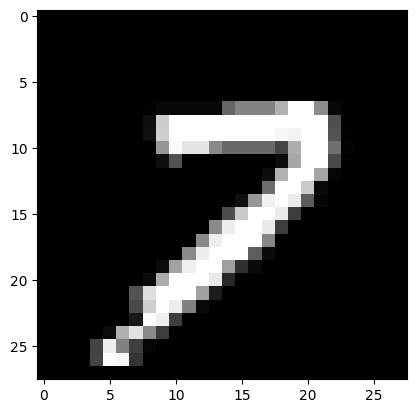

Predicted value: 7
Actual value: 4



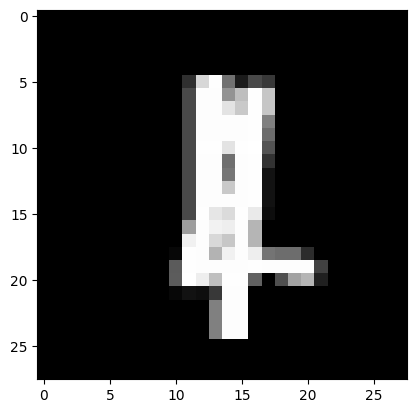

Predicted value: 1
Actual value: 4



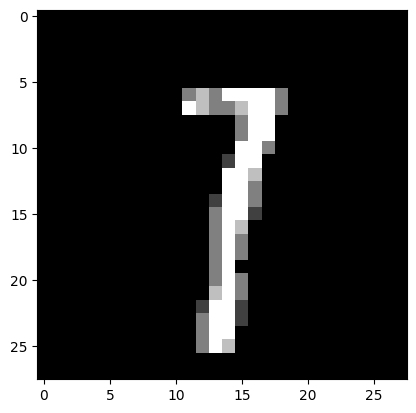

Predicted value: 7
Actual value: 1



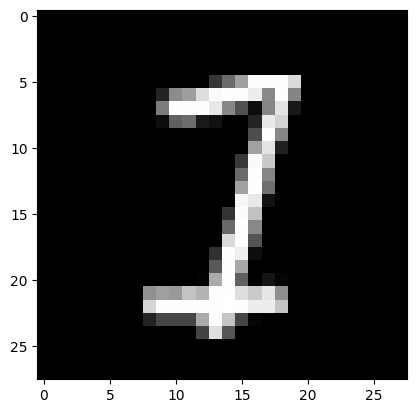

Predicted value: 1
Actual value: 7



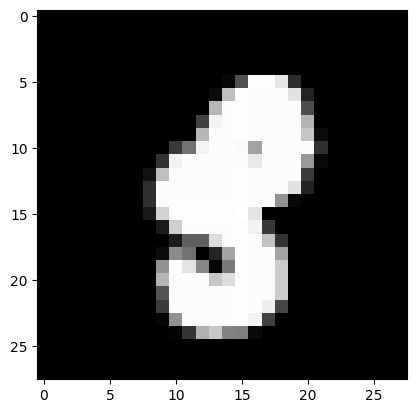

Predicted value: 8
Actual value: 3



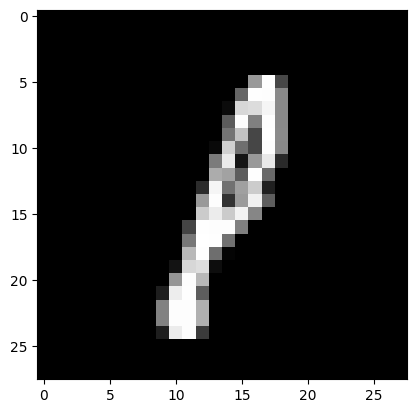

Predicted value: 1
Actual value: 8



In [11]:
with torch.no_grad():
    errors = 0
    for images, labels in train_loader:
        for i, (image, label) in enumerate(zip(images, labels)):
            image = image.view(-1, 28 * 28).to(device)
            _, prediction = torch.max(net(image), 1)
            if prediction.item() != label.item():
                plt.imshow(image.view(28, 28).cpu(), cmap='gray')
                plt.show()
                print(f"Predicted value: {prediction.item()}")
                print(f"Actual value: {label.item()}")
                print()
                errors += 1
        if errors >= 10:
            break

In [24]:
transformer = transforms.Compose([transforms.Grayscale(num_output_channels=1),
                                  transforms.Resize((28, 28)),
                                  transforms.RandomInvert(p=1.0),
                                  transforms.ToTensor()])

In [1]:
img = Image.open("source/images/four.jpg")
image = transformer(img)
with torch.no_grad():
    plt.imshow(img, cmap='gray_r')
    plt.show()
    plt.imshow(image.view(28, 28), cmap='gray')
    plt.show()
    image = image.view(-1, 28 * 28).to(device)
    _, prediction = torch.max(net(image), 1)
    print(f"Predicted value: {prediction.item()}")
    print(f"Actual value: {4}")
    print()

NameError: name 'Image' is not defined